# Predicting Developer Salaries

Stack Overflow Developer Survey 2025 subsample, 5,000 responses. Target: `annual_salary_usd`.

Cleaning removes 586 rows (11.7%). The model is a `HistGradientBoostingRegressor` over 84 features,
scored out-of-fold against two baselines and a regularised linear model on identical folds:

| model | MAE | MedAE | RMSE | R2_log |
|---|---|---|---|---|
| global median | $47,332 | $36,289 | $65,812 | -0.009 |
| country median | $35,614 | $24,181 | $52,326 | 0.375 |
| Ridge (one-hot) | $29,761 | $18,831 | $45,851 | 0.570 |
| **HGB** | **$27,808** | **$17,409** | **$43,297** | **0.598** |

Section 8 is the part worth reading: `Country` alone accounts for more of the model's measured
performance than the other 83 features put together -- which is also why Ridge lands so close.

`pip install -r requirements.txt`, then Restart & Run All. Every number in the prose is produced by
a cell above it.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

RANDOM_SEED = 0
N_FOLDS = 5

df_raw = pd.read_csv("data/survey.csv")
assert df_raw.shape == (5000, 16), f"unexpected shape: {df_raw.shape}"
print(f"{df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

5,000 rows x 16 columns


,ResponseId,Age,EdLevel,Employment,WorkExp,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,Industry,Country,Currency,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,annual_salary_usd
0,1,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,Fintech,Ukraine,EUR European Euro,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,61256.0
1,10004,55-64 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,40.0,46.0,"Developer, full-stack","10,000 or more employees",Individual contributor,"Your choice (very flexible, you can come in wh...",Computer Systems Design and Services,Germany,EUR European Euro,C#;Java;SQL,H2;MariaDB;Neo4J;Oracle,99773.0
2,10016,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,2.0,5.0,"Developer, full-stack","10,000 or more employees",Individual contributor,Remote,Healthcare,United States of America,USD United States dollar,Bash/Shell (all shells);C#;HTML/CSS;JavaScript...,Microsoft SQL Server;MongoDB,85000.0


---
# 1. Column-by-column audit

Look at everything before changing anything. Cleaning destroys evidence: once you drop the $1
salaries you can no longer investigate whether they were monthly figures.

In [2]:
def audit(df):
    """One row per column: dtype, completeness, cardinality, most common value."""
    def most_common(s):
        vc = s.value_counts()
        return f"{str(vc.index[0])[:38]}  ({vc.iloc[0]:,})"
    return pd.DataFrame({
        "dtype":       df.dtypes.astype(str),
        "non_null":    df.notna().sum().map("{:,}".format),
        "pct":         (df.notna().mean() * 100).round(1),
        "distinct":    df.nunique().map("{:,}".format),
        "most_common": df.apply(most_common),
    })

# why: one line per column rather than a per-column dump -- the decisions this feeds are in the
#      verdict table below, and a 16-row frame is readable where 178 lines of value_counts is not
audit(df_raw)

,dtype,non_null,pct,distinct,most_common
ResponseId,int64,"5,000",100.0,"5,000",1 (1)
Age,str,"5,000",100.0,7,"25-34 years old (1,892)"
EdLevel,str,"4,995",99.9,8,"Bachelor’s degree (B.A., B.S., B.Eng., (2,283)"
Employment,str,"5,000",100.0,6,"Employed (4,215)"
WorkExp,float64,"4,948",99.0,54,10.0 (348)
YearsCode,float64,"4,979",99.6,57,10.0 (360)
DevType,str,"5,000",100.0,32,"Developer, full-stack (1,790)"
OrgSize,str,"4,470",89.4,9,20 to 99 employees (961)
ICorPM,str,"4,398",88.0,2,"Individual contributor (3,844)"
RemoteWork,str,"4,447",88.9,5,"Remote (1,554)"


## Column verdicts

`KEEP` (use as-is) / `CLEAN` (fix something first) / `ENGINEER` (needs encoding) / `DROP`.
All counts describe the 5,000 raw rows, before any cleaning.

| Column | Verdict | Why |
|---|---|---|
| `ResponseId` | DROP | 5,000 distinct values in 5,000 rows, so it is an identifier, not a feature -- a tree handed it would memorise rows. `clean()` keeps it in `df` only so section 9 can label predictions, and `build_features()` never selects it. It is also why the dedup excludes it: it hides the one otherwise-identical pair. |
| `Age` | ENGINEER | 7 levels -- 6 ordered bands plus "Prefer not to say" (6 rows). Ordinal 0-5, with the non-answer sent to NaN rather than placed somewhere on the scale. |
| `EdLevel` | ENGINEER | 8 levels -- 7 rungs of a ladder plus "Other (please specify):" (48 rows), and 5 blanks. Ordinal 0-6, "Other" and blanks to NaN. Two level names contain a curly apostrophe (U+2019), so the order list must match the CSV exactly; a one-character typo would silently turn the column into missing data, which is what the assert in section 4 guards. |
| `Employment` | ENGINEER | 6 unordered levels, no blanks. Category dtype. Also the column that explains most of the missingness elsewhere -- `OrgSize`, `ICorPM` and `RemoteWork` are blank largely for people who are not conventionally employed, so the model needs this one to read those NaNs correctly. |
| `WorkExp` | KEEP | Float years, 52 blanks, range 1-100. No imputation: HGB splits on NaN natively. The 7 rows above 50 years are implausible but too few to move anything, and 199 rows report more work experience than years coding -- possible if that experience was not all coding, so left alone rather than "corrected" on a guess. |
| `YearsCode` | KEEP | Same treatment. Float, 21 blanks, range 1-100, 9 rows above 50. |
| `DevType` | ENGINEER | 32 unordered levels, no blanks. Category dtype with every level kept -- the 9 levels holding under 20 rows cover just 74 rows between them, a small enough share to leave alone. |
| `OrgSize` | ENGINEER | 9 levels, but only 8 are positions on a size scale. "I don't know" (47 rows, curly apostrophe again) is a non-answer, not a size. Ordinal over the 8, with that level and the 530 blanks going to NaN. |
| `ICorPM` | ENGINEER | Only 2 real values against 602 blanks. Category dtype, and the NaN is informative rather than missing: it marks people the question does not apply to, which `Employment` already accounts for. |
| `RemoteWork` | ENGINEER | 5 unordered levels, 553 blanks. Category dtype -- "Hybrid" and "Your choice" have no defensible rank between them, so an ordinal would assert an order that is not there. |
| `Industry` | ENGINEER | 15 unordered levels, 144 blanks. Category dtype, no natural order. |
| `Country` | ENGINEER | 130 levels, no blanks. Category dtype, ungrouped -- well under HGB's 255-category ceiling. The strongest single predictor by a wide margin: the country-median baseline in section 5 reaches most of the way to the full model on this column alone. |
| `Currency` | CLEAN | 97 values, and 1,133 rows separate the 3-letter code from the currency name with a tab instead of a space, so the raw string is an unreliable key. Split on whitespace, keep `currency_code`, drop the original. |
| `LanguageHaveWorkedWith` | ENGINEER | Semicolon-joined lists: 2,940 distinct strings collapse to 42 tokens. Multi-hot, one column per language. The 349 blanks become all-zero rows. |
| `DatabaseHaveWorkedWith` | ENGINEER | Same shape -- 1,672 strings collapse to 30 tokens. Caveat: the 1,052 blanks also become all-zero, so "did not answer" and "uses no database" are indistinguishable to the model. |
| `annual_salary_usd` | TARGET | 84 blanks, range $1 to $6,890,299, and only 2,103 distinct values across 4,916 answers -- far too few for a continuous field, which is the thread that leads to the repeated EUR figures two cells down. Rows with no target are dropped, the rest trimmed to $10k-$400k, and the model fits `log1p` of it. |


---
# 2. The target

Everything downstream depends on understanding this column first.

In [3]:
y_raw = df_raw.annual_salary_usd

print("missing:", y_raw.isna().sum(), "rows\n")
print(y_raw.describe().to_string())
print("\nquantiles:")
print(y_raw.quantile([.001, .01, .05, .25, .5, .75, .95, .99, .999]).to_string())
print(f"\nbelow $1,000: {(y_raw < 1_000).sum()}    below $5,000: {(y_raw < 5_000).sum()}"
      f"    above $1M: {(y_raw > 1_000_000).sum()}")

missing: 84 rows

count    4.916000e+03
mean     9.835268e+04
std      1.454344e+05
min      1.000000e+00
25%      4.176500e+04
50%      7.755900e+04
75%      1.239930e+05
max      6.890299e+06

quantiles:
0.001          3.0
0.010         85.6
0.050       3988.0
0.250      41765.0
0.500      77559.0
0.750     123993.0
0.950     232029.0
0.990     500000.0
0.999    1291668.7

below $1,000: 124    below $5,000: 282    above $1M: 8


raw skew     23.85
log1p skew   -2.64


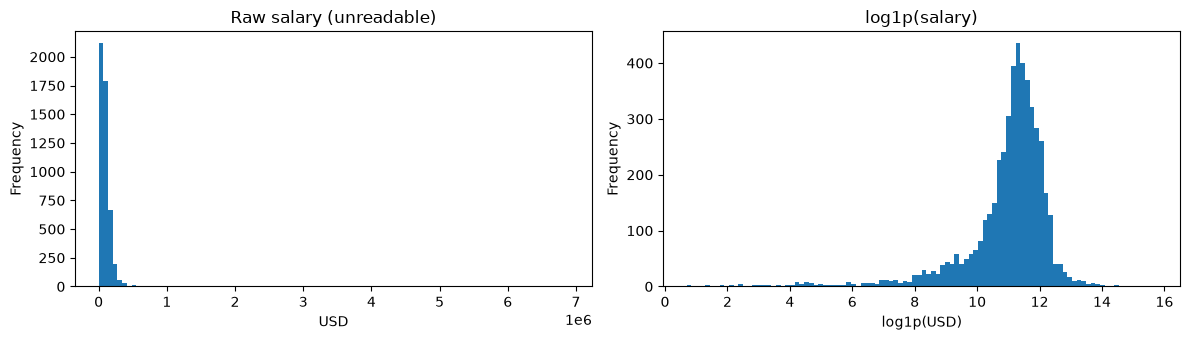

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
y_raw.dropna().plot.hist(bins=100, ax=ax[0], title="Raw salary (unreadable)")
np.log1p(y_raw.dropna()).plot.hist(bins=100, ax=ax[1], title="log1p(salary)")
ax[0].set_xlabel("USD"); ax[1].set_xlabel("log1p(USD)")
plt.tight_layout()

print(f"raw skew   {y_raw.skew():>7.2f}")
print(f"log1p skew {np.log1p(y_raw).skew():>7.2f}")

### The two tails

Both tails are visible in the plot above and they fail for different reasons, so they need separate
verdicts before any threshold gets picked.

**The bottom is broken data.** The 15 smallest are $1 to $10 -- values like 1.0 for an employed
developer in Indonesia or 3.0 in Taiwan. No salary is one dollar. The obvious reading is a figure
entered in a different unit or period, but `CompFreq` (weekly / monthly / yearly) is not in this
subsample, so there is nothing to multiply by. These rows can be identified as wrong and cannot be
repaired, which makes dropping them the only honest option.

**The top is a mixture.** $6,890,299 for a Ukrainian freelancer paid in hryvnia is not a salary; it
is almost certainly a hryvnia figure that escaped conversion. But nine of the top fifteen are US
employees between $900,000 and $2,000,000, and those are rare rather than impossible. There is no
field that separates the real ones from the broken ones, so any upper cut is a judgement about how
much genuine right tail to sacrifice -- which is why section 3 measures the trade instead of
guessing at it.

Worth noting for later: `Currency` disagrees with `Country` in places (Iceland paired with Polish
zloty, Germany with USD), and the currency codes are separated by a tab rather than a space.

In [5]:
cols = ["Country", "Currency", "Employment", "annual_salary_usd"]
print("15 largest:")
print(df_raw.nlargest(15, "annual_salary_usd")[cols].to_string())
print()
print("15 smallest:")
print(df_raw.nsmallest(15, "annual_salary_usd")[cols].to_string())

15 largest:
                       Country                  Currency                                            Employment  annual_salary_usd
3236                   Ukraine     UAH Ukrainian hryvnia  Independent contractor, freelancer, or self-employed          6890299.0
1858                     India  USD United States dollar                                              Employed          2500000.0
2896  United States of America  USD United States dollar                                              Employed          2000000.0
4493  United States of America  USD United States dollar                                              Employed          1950000.0
3294                   Finland         EUR European Euro                                              Employed          1740220.0
2083  United States of America  USD United States dollar                                              Employed          1250000.0
2614               Netherlands         EUR European Euro                      

In [6]:
# A continuous salary field should have almost no exact duplicates. This one does.
print(y_raw.value_counts().head(8).to_string())

print("\ncurrency of the 3 most repeated values:")
top3 = y_raw.value_counts().head(3).index
print(df_raw[df_raw.annual_salary_usd.isin(top3)]
      .groupby(["annual_salary_usd", "Currency"]).size().to_string())

annual_salary_usd
69609.0     66
116015.0    60
92812.0     54
58007.0     53
81210.0     52
46406.0     47
75410.0     44
63808.0     43

currency of the 3 most repeated values:
annual_salary_usd  Currency         
69609.0            EUR European Euro    66
92812.0            EUR European Euro    54
116015.0           EUR European Euro    60


## What the repeated values are

Not 66 people who happen to earn the same amount. They are people who typed a round number of
euros, run through one fixed conversion rate applied to the whole file.

The ratios between the repeated values give it away first. They are exact simple fractions, which
is what you get when the same unit is scaled rather than when independent numbers coincide:

- 116,015 / 69,609 = 1.6667 (5/3)
- 69,609 / 58,007 = 1.2000 (6/5)
- 92,812 / 58,007 = 1.6000 (8/5)

Assume the most-repeated cluster is a round 50,000 EUR and the implied rate is
58,007 / 50,000 = **1.16014 USD per EUR**. Divide the repeated values by it:

| USD in the file | rows | as EUR |
|---|---|---|
| 58,007 | 53 | 50,000 |
| 69,609 | 66 | 60,000 |
| 75,410 | 44 | 65,000 |
| 81,210 | 52 | 70,000 |
| 92,812 | 54 | 80,000 |
| 104,413 | 36 | 90,000 |
| 116,015 | 60 | 100,000 |

Every one. And it is not confined to the top of the list: of the 1,449 EUR rows with a salary,
**1,181 (81.5%) land within a euro of a round 1,000** once divided by that rate.

The distinctness counts say the same thing from the other side. A continuous dollar field should be
almost entirely unique, and the non-EUR rows roughly behave: 1,798 distinct values across 3,467
rows (51.9%). The EUR rows collapse to 313 distinct values across 1,449 rows (**21.6%**). The euro
answers are quantised because they started life on a coarser grid.

USD respondents round too -- 150,000 and 200,000 both appear 40+ times. The difference is that
their round numbers survive as round numbers, while the euro ones arrive disguised as precise
figures like 69,609.

## What this changes

**`Currency` is signal, not bookkeeping.** Everyone paid in euros went through the same arithmetic,
so the currency identifies a shared processing step that `Country` cannot: it splits the Eurozone
about twenty ways. That is the argument for carrying `currency_code` into the feature set in
section 4, and it is why `clean()` bothers to repair the tab-separated `Currency` string at all.

**The target's precision is fake.** A figure like 69,609 looks accurate to the dollar and is really
"about sixty thousand euros, converted". Judging errors in absolute dollars would be pretending to
a resolution the data never had, which is part of why the model fits `log1p` and why the evaluation
reports MedAE next to MAE.

## What it does not license

It is tempting to reach for the same trick on the low tail -- 124 rows under $1,000 -- and try to
recover a monthly figure by multiplying by 12. Don't. `CompFreq`, the column that records whether a
respondent answered weekly, monthly or yearly, is not in this subsample. Without it there is no way
to tell a genuine low salary from a monthly one, and multiplying on a hunch would invent data.

So the low tail gets trimmed rather than repaired, and the trim threshold is chosen by measurement
in section 3 rather than by a story about what those numbers might have been.


---
# 3. Cleaning

One function, every threshold a named constant, every line justified.

### The trim decision, measured before it is made

The cell below holds the model fixed and changes only the filter, so any difference in score is
caused by the filter alone. The thresholds in `clean()` are picked from this table.

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict

_CATS = ["Age", "EdLevel", "Employment", "DevType", "OrgSize",
         "RemoteWork", "Industry", "Country"]

def _quick_X(d):
    """Minimal feature frame, only for the sensitivity test below."""
    X = d[_CATS].astype("category").copy()
    X["WorkExp"] = d.WorkExp.values
    X["YearsCode"] = d.YearsCode.values
    return X

def trim_sensitivity(df, rules):
    base = df.dropna(subset=["annual_salary_usd"])
    kf = KFold(N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    rows = []
    for name, lo, hi in rules:
        d = base[base.annual_salary_usd.between(lo, hi)]
        y = np.log1p(d.annual_salary_usd.values)
        X = _quick_X(d)
        m = HistGradientBoostingRegressor(
            categorical_features=[str(t) == "category" for t in X.dtypes],
            random_state=RANDOM_SEED, max_iter=300, learning_rate=0.06)
        p = cross_val_predict(m, X, y, cv=kf)
        actual, pred = np.expm1(y), np.expm1(p)
        rows.append({
            "rule": name, "n": len(d),
            "MAE": np.abs(actual - pred).mean(),
            "MedAE": np.median(np.abs(actual - pred)),
            "R2_log": 1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum(),
        })
    return pd.DataFrame(rows).set_index("rule")

RULES = [
    ("keep everything",  0,      np.inf),
    ("drop < $1k",       1_000,  np.inf),
    ("drop < $5k",       5_000,  np.inf),
    ("$5k - $500k",      5_000,  500_000),
    ("$10k - $400k",     10_000, 400_000),
]
trim_sensitivity(df_raw, RULES).round({"MAE": 0, "MedAE": 0, "R2_log": 3})

,n,MAE,MedAE,R2_log
rule,,,,
keep everything,4916,42964.0,22964.0,0.326
drop < $1k,4792,39280.0,20754.0,0.502
drop < $5k,4634,39519.0,20201.0,0.514
$5k - $500k,4588,30982.0,18904.0,0.540
$10k - $400k,4415,29924.0,19222.0,0.549


In [8]:
MIN_SALARY = 10_000    # why: the floor is what fixes R2_log -- 0.326 -> 0.502 -> 0.514 as it rises $0 -> $1k -> $5k at a fixed ceiling
MAX_SALARY = 400_000   # why: the ceiling is what fixes MAE -- at a fixed $5k floor, capping cut MAE $39,519 -> $30,982

def clean(df, trim=None):
    df = df.copy()                                                          # why: caller keeps df_raw intact for the before/after comparison
    df = df[df.annual_salary_usd.notna()]                                   # why: 84 rows have no y -- unscorable, and imputing a target invents the answer
    keep = trim(df) if trim is not None else df.annual_salary_usd.between(MIN_SALARY, MAX_SALARY)
    df = df[keep]                                                           # why: .between() is False for NaN, so this would silently absorb the line above; separating them keeps the 84 attributable
    # why: `trim` is a parameter so section 8 can re-run the entire pipeline under a different
    #      rule without duplicating these steps -- the alternative would drift from this one
    df = df.drop_duplicates(subset=df.columns.drop("ResponseId"))           # why: ResponseId is unique by construction, so it hides the one otherwise-identical pair (4119 / 15999)
    df["currency_code"] = df.Currency.str.split(r"\s+", regex=True).str[0]  # why: 1,133 of 5,000 rows separate code from name with a tab, so the raw string is an unreliable key
    # flagged: ResponseId stays because section 9 writes it to predictions.csv; ICorPM stays because
    # +0.0006 importance is a feature-selection call, not a data defect -- build_features() never selects it.
    return df.drop(columns=[
        "Currency",   # why: currency_code holds the same 97 levels behind a stable key, so the raw string is dead weight
    ])

df = clean(df_raw)
print(f"{len(df_raw):,} rows -> {len(df):,} rows  ({len(df_raw) - len(df):,} removed)")

5,000 rows -> 4,414 rows  (586 removed)


In [9]:
# Each assert states a guarantee clean() is supposed to make. If one fires the pipeline stops
# here, rather than training on a frame that no longer means what the code above says it means.
# _target, not y: from section 4 onward `y` means log1p dollars, and one name per meaning.

_target = df.annual_salary_usd

assert _target.notna().all(), f"{_target.isna().sum()} null targets survived the dropna"
assert _target.between(MIN_SALARY, MAX_SALARY).all(), \
    f"target escaped the trim: min={_target.min():,.0f} max={_target.max():,.0f}"
assert not df.drop(columns="ResponseId").duplicated().any(), \
    f"{df.drop(columns='ResponseId').duplicated().sum()} duplicate rows survived"
assert 4_300 <= len(df) <= 4_500, \
    f"row count {len(df):,} is outside the band this trim produces -- a filter changed meaning"
# ^ recompute the band if you change MIN_SALARY / MAX_SALARY. Its job is to catch a filter that
#   silently stopped filtering, which a spot-check of df.head() would never show.

_kept = df_raw.dropna(subset=["annual_salary_usd"])
_trim = _kept[_kept.annual_salary_usd.between(MIN_SALARY, MAX_SALARY)]
print(f"before : {len(df_raw):,}")
print(f"after  : {len(df):,}  ({len(df_raw) - len(df):,} removed, {1 - len(df) / len(df_raw):.1%})")
print(f"  null target     -{len(df_raw) - len(_kept):>4}")
print(f"  outside trim    -{len(_kept) - len(_trim):>4}")
print(f"  exact duplicate -{len(_trim) - len(df):>4}")

before : 5,000
after  : 4,414  (586 removed, 11.7%)
  null target     -  84
  outside trim    - 501
  exact duplicate -   1


---
# 4. Features

Encode by column *kind*. Numeric needs nothing, ordered categories get integer codes in the real
order, unordered categories stay categorical, list-valued columns get multi-hot.

In [10]:
# Ordered categories: EdLevel, OrgSize, Age. Each keeps only the levels that are genuine
# positions on its scale; non-answers are handled below.

ED_ORDER = [
    "Primary/elementary school",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",
    "Some college/university study without earning a degree",
    "Associate degree (A.A., A.S., etc.)",
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)",
]
# note the curly apostrophe U+2019 -- these strings must match the CSV exactly.
# verify: set(ED_ORDER) - set(df_raw.EdLevel.dropna())   # should print set()

# OrgSize has 9 distinct values, but only 8 of them are positions on a size scale.
ORG_ORDER = [
    "Just me - I am a freelancer, sole proprietor, etc.",   # why: a company of one is the smallest size there is, so it anchors the scale rather than sitting off it
    "Less than 20 employees",
    "20 to 99 employees",
    "100 to 499 employees",
    "500 to 999 employees",
    "1,000 to 4,999 employees",
    "5,000 to 9,999 employees",
    "10,000 or more employees",
]
# why: "I don't know" (39 rows, spelt with U+2019 in the CSV) is deliberately absent -- it is a
# non-answer, not a size, and every position on the scale would assert something false about it.
# ordinal() sends it to NaN instead, which HGB splits on natively.

AGE_ORDER = [
    "18-24 years old", "25-34 years old", "35-44 years old",
    "45-54 years old", "55-64 years old", "65 years or older",
]
# why: "Prefer not to say" (5 rows) absent for the same reason -- no age band it belongs beside.

def ordinal(series, order):
    """Map an ordered category to 0..n-1. Values outside `order` become NaN."""
    return series.map({v: i for i, v in enumerate(order)}).astype("float")

In [11]:
def multi_hot(series, prefix):
    """Split a ';'-joined column into one 0/1 column per token."""
    return series.fillna("").str.get_dummies(";").add_prefix(prefix)

# sanity check: raw-string cardinality vs token count
_lang = df_raw.LanguageHaveWorkedWith.fillna("")
print(f"raw string as a category : {_lang.nunique():>5} values")
print(f"multi-hot tokens         : {multi_hot(_lang, 'lang_').shape[1]:>5} columns")

raw string as a category :  2941 values
multi-hot tokens         :    42 columns


In [12]:
CAT_UNORDERED = [
    "Employment",      # why: also the key to every missing-value pattern below, so the model needs it to read those NaNs correctly
    "DevType",         # why: all 32 levels kept -- collapsing the 11 rare ones (85 rows) moved MAE by $95 and R2_log by -0.0002, so the code would buy nothing
    "RemoteWork",      # why: 5 levels with no defensible rank -- "Your choice" sits neither above nor below "Hybrid"
    "Industry",        # why: 15 levels, no natural order
    "Country",         # why: the strongest single predictor, and 130 levels is well under HGB's 255-category ceiling, so it needs no grouping
    "ICorPM",          # why: kept from clean(); its NaN doubles as a not-applicable marker that Employment already explains
    "currency_code",   # why: puts the Eurozone in one level that Country splits 20 ways -- measured MAE -$287, R2_log +0.005
]

def build_features(df):
    num = pd.DataFrame(index=df.index)                      # why: gather the numeric block in one place so the concat below is the only thing that assembles X
    num["WorkExp"] = df.WorkExp                             # why: already years on a real scale; HGB splits on NaN natively, so the 29 blanks need no imputer
    num["YearsCode"] = df.YearsCode                         # why: same, 13 blanks
    num["EdLevel_ord"] = ordinal(df.EdLevel, ED_ORDER)      # why: 41 rows -> NaN (36 "Other (please specify):" + 5 blank), which is right -- neither is a rung on the ladder
    num["Age_ord"] = ordinal(df.Age, AGE_ORDER)             # why: the 5 "Prefer not to say" rows -> NaN
    num["OrgSize_ord"] = ordinal(df.OrgSize, ORG_ORDER)     # why: 450 rows -> NaN (411 blank + 39 "I don't know"), and the crosstab shows Employment explains nearly all of them
    X = pd.concat([
        df[CAT_UNORDERED].astype("category"),               # why: NaN stays NaN -- a literal "Missing" level scored identically to 4 decimals, because HGB already gives NaN its own bin
        num,
        multi_hot(df.LanguageHaveWorkedWith, "lang_"),      # why: +42 columns, and the tech block is the biggest single win measured (MAE -$1,798, R2_log +0.041)
        multi_hot(df.DatabaseHaveWorkedWith, "db_"),        # why: +30 columns; caveat -- fillna("") leaves 882 non-answers indistinguishable from "uses no database"
    ], axis=1)
    # ResponseId and annual_salary_usd are simply never selected. That is how clean() gets to keep
    # ResponseId for section 9 without it ever reaching the model.
    y = np.log1p(df.annual_salary_usd.values)               # why: takes the cleaned target's skew from +1.36 to -0.52, so neither tail dominates the squared error, and error in log space is proportional -- which is how a salary miss is actually judged
    return X, y, [str(t) == "category" for t in X.dtypes]   # why: cat_mask is read off the dtypes instead of hand-written, so it cannot drift out of sync with X's columns

X, y, cat_mask = build_features(df)
print(f"X: {X.shape[0]:,} rows x {X.shape[1]} features")

X: 4,414 rows x 84 features


In [13]:
# ordinal() maps any unmatched string to NaN, so one wrong character in a 60-char level name turns
# a whole column into missing data without raising. These check both directions of that mistake.

for _name, _order, _col in [("ED_ORDER", ED_ORDER, df.EdLevel),
                            ("ORG_ORDER", ORG_ORDER, df.OrgSize),
                            ("AGE_ORDER", AGE_ORDER, df.Age)]:
    assert len(_order) == len(set(_order)), f"{_name} lists a level twice"
    assert not set(_order) - set(_col.dropna()), \
        f"{_name} contains levels the data does not (typo?): {set(_order) - set(_col.dropna())}"

# The levels left out on purpose, named explicitly. A new survey level then fails here instead of
# silently becoming NaN in a future run.
assert set(df.EdLevel.dropna()) - set(ED_ORDER) == {"Other (please specify):"}
assert set(df.OrgSize.dropna()) - set(ORG_ORDER) == {"I don’t know"}
assert set(df.Age.dropna()) - set(AGE_ORDER) == {"Prefer not to say"}

assert len(X) == len(y) == len(df), f"row count changed: X={len(X)} y={len(y)} df={len(df)}"
assert len(cat_mask) == X.shape[1], f"cat_mask is {len(cat_mask)} long but X has {X.shape[1]} columns"
assert X.columns.is_unique, "duplicate column name -- a lang_/db_ token collision"
assert not np.isnan(y).any(), "log1p produced NaN, so a non-positive salary got past the trim"
assert 80 <= X.shape[1] <= 90, f"{X.shape[1]} features -- the tech block changed size, recheck it"

print(f"X: {X.shape[0]:,} rows x {X.shape[1]} features  "
      f"({sum(cat_mask)} categorical, "
      f"{sum(c.startswith(('lang_', 'db_')) for c in X.columns)} tech, "
      f"{X.shape[1] - sum(cat_mask) - sum(c.startswith(('lang_', 'db_')) for c in X.columns)} numeric)")
print("y: log1p dollars, range "
      f"{y.min():.2f}-{y.max():.2f}  (= ${np.expm1(y.min()):,.0f}-${np.expm1(y.max()):,.0f})")
print("ordinal -> NaN:",
      {c: int(X[c].isna().sum()) for c in ["EdLevel_ord", "Age_ord", "OrgSize_ord"]})

X: 4,414 rows x 84 features  (7 categorical, 72 tech, 5 numeric)
y: log1p dollars, range 9.21-12.90  (= $10,000-$400,000)
ordinal -> NaN: {'EdLevel_ord': 41, 'Age_ord': 5, 'OrgSize_ord': 450}


---
# 5. Baselines

**Build these before the model.** If you fit the model first you'll anchor on its number and the
baseline becomes a formality instead of a test.

A metric with nothing to compare against is not a result.

### Two baselines

**Baseline 0 -- global median.** The same number for every respondent, ignoring all features. Its
job is to confirm the metric is calibrated: R2_log near zero is what a no-information predictor
should score.

**Baseline 1 -- country median.** The median salary of the respondent's country, and the real
opponent for the model.

Baseline 1 has a trap. Computing each country's median from *all* rows lets every test row's own
salary help produce the number it is scored against, which inflates the baseline and flatters the
model by comparison. So it is computed **out-of-fold**: the same `KFold` splitter the model uses,
medians built from training rows only, with countries absent from a training fold falling back to
that fold's global median.

In [14]:
kf = KFold(N_FOLDS, shuffle=True, random_state=RANDOM_SEED)   # why: one splitter object, reused by section 6, so every model below is scored on identical folds

country = df.Country.values             # why: .values because KFold yields positions, and positions index arrays, not labels

oof_global = np.full(len(y), np.nan)    # why: NaN not zeros -- an unfilled slot then fails an assert instead of passing as a plausible prediction
oof_country = np.full(len(y), np.nan)
n_fallback = 0

for tr, te in kf.split(X):
    train_median = np.median(y[tr])                               # why: the median of log1p equals log1p of the median, so working in log space costs nothing here
    oof_global[te] = train_median                                 # why: baseline 0 -- ignores every feature, exists to put R2_log ~ 0 on the board
    by_country = pd.Series(y[tr]).groupby(country[tr]).median()   # why: TRAIN rows only -- computed on all 4,414 this flatters R2_log by +0.047, because each test row then helped set the bar it is judged against
    hit = pd.Series(country[te]).map(by_country)                  # why: NaN wherever this fold's training rows held nobody from that country
    n_fallback += int(hit.isna().sum())
    oof_country[te] = hit.fillna(train_median).values             # why: the global median is the only estimate left for a country the model never saw

assert not np.isnan(oof_global).any(), "a row never landed in a test fold"
assert not np.isnan(oof_country).any(), f"{np.isnan(oof_country).sum()} rows kept a NaN prediction"

print(f"baseline 0: {len(np.unique(oof_global))} distinct predictions across {N_FOLDS} folds, "
      f"${np.expm1(oof_global).min():,.0f}-${np.expm1(oof_global).max():,.0f}")
print(f"baseline 1: {n_fallback} rows ({n_fallback / len(y):.1%}) fell back to the global median")


baseline 0: 4 distinct predictions across 5 folds, $81,318-$83,531
baseline 1: 34 rows (0.8%) fell back to the global median


---
# 6. Model

### Fitting

`HistGradientBoostingRegressor` takes categoricals and NaN natively, so there is no encoder and no
imputer to leak through -- the `categorical_features=cat_mask` mask is read off `X`'s dtypes in
section 4, so it cannot drift from the columns it describes.

`cross_val_predict` runs on the **same** `KFold` object as both baselines, so section 7 compares
like with like. Every prediction it returns comes from a model that never saw that row.

In [15]:
model = HistGradientBoostingRegressor(
    categorical_features=cat_mask,   # why: read off X's dtypes in section 4, so it cannot drift from the columns it describes
    random_state=RANDOM_SEED,
    max_iter=300,                    # why: the same settings the section 3 trim test used, so that experiment really did hold the model fixed
    learning_rate=0.06,
)
oof_model = cross_val_predict(model, X, y, cv=kf)   # why: the same kf object as both baselines -- identical folds, so section 7 compares like with like

assert oof_model.shape == y.shape, f"{oof_model.shape} predictions for {y.shape} targets"
print(f"out-of-fold predictions for {len(oof_model):,} rows, "
      f"${np.expm1(oof_model).min():,.0f}-${np.expm1(oof_model).max():,.0f}")


out-of-fold predictions for 4,414 rows, $12,474-$341,777


### A linear model to price the choice

HGB was picked partly because it takes categoricals and NaN natively. The way to find out whether
that convenience is also an advantage is to fit a model that needs the whole encoding stack --
one-hot, imputation, scaling -- on the same features and the same folds, and see what the
difference actually is.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols  = [c for c, is_cat in zip(X.columns, cat_mask) if is_cat]   # why: the same mask HGB uses, so both models treat the same columns as categorical
tech_cols = [c for c in X.columns if c.startswith(("lang_", "db_"))]
num_cols  = [c for c in X.columns if c not in cat_cols and c not in tech_cols]

ridge = make_pipeline(
    ColumnTransformer([
        ("cat",  OneHotEncoder(handle_unknown="ignore", min_frequency=5), cat_cols),
        # why: handle_unknown because a country in a test fold may be absent from that fold's training rows,
        #      which would otherwise raise; min_frequency pools the rare levels instead of fitting a
        #      coefficient to each on a handful of rows
        ("num",  make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_cols),
        # why: Ridge cannot take NaN, and its penalty is scale-dependent so unscaled columns would be
        #      shrunk unevenly. This is exactly the encoder-and-imputer stack HGB did not need.
        ("tech", "passthrough", tech_cols),   # why: already 0/1, nothing to encode or scale
    ]),
    RidgeCV(alphas=np.logspace(-1, 3, 20)),
    # why: alpha is chosen inside each training fold by RidgeCV's own internal CV, so no test row
    #      influences the penalty it is later scored under
)

oof_ridge = cross_val_predict(ridge, X, y, cv=kf)   # why: the same kf object again -- four models, identical folds
assert oof_ridge.shape == y.shape, f"{oof_ridge.shape} predictions for {y.shape} targets"

ridge.fit(X, y)   # why: refit on everything only to report the width and alpha below, never to score
print(f"one-hot expands {X.shape[1]} features to {ridge[:-1].transform(X).shape[1]} columns")
print(f"alpha selected on the full data: {ridge[-1].alpha_:.1f}")

one-hot expands 84 features to 241 columns
alpha selected on the full data: 7.8


---
# 7. Evaluation

Metrics in dollars, not log-dollars. Nobody can interpret "MAE of 0.42".

In [17]:
def report(name, y_true_log, y_pred_log):
    """Back-transform to dollars and return the four metrics."""
    actual, pred = np.expm1(y_true_log), np.expm1(y_pred_log)
    ss_res = ((y_true_log - y_pred_log) ** 2).sum()
    ss_tot = ((y_true_log - y_true_log.mean()) ** 2).sum()
    return {
        "model":  name,
        "MAE":    np.abs(actual - pred).mean(),
        "MedAE":  np.median(np.abs(actual - pred)),
        "RMSE":   np.sqrt(((actual - pred) ** 2).mean()),
        "R2_log": 1 - ss_res / ss_tot,
    }

results = pd.DataFrame([
    report("global median",  y, oof_global),    # why: the floor -- R2_log near 0 is the check that the metric itself is calibrated
    report("country median", y, oof_country),   # why: the real opponent, one feature, and it closes most of the gap
    report("Ridge",          y, oof_ridge),     # why: the same 84 features through a full encoding stack, to price what HGB's native handling is worth
    report("HGB",            y, oof_model),     # why: 84 features, scored on the same folds as the three above
]).set_index("model")
results.round({"MAE": 0, "MedAE": 0, "RMSE": 0, "R2_log": 3})


,MAE,MedAE,RMSE,R2_log
model,,,,
global median,47332.0,36289.0,65812.0,-0.009
country median,35614.0,24181.0,52326.0,0.375
Ridge,29761.0,18831.0,45851.0,0.570
HGB,27808.0,17409.0,43297.0,0.598


### What the gap between Ridge and HGB says

Ridge reaches R2_log 0.570 against HGB's 0.598, and MAE $29,761 against $27,808. The boosting wins
on every metric, but by 0.028 of R2_log -- far less than "trees beat linear models on tabular data"
would lead you to expect.

That narrow gap is the `Country` finding from section 8 seen from the other side. If one
high-cardinality categorical carries most of the signal, then most of what any model can learn here
is a per-country offset -- and in log space an offset is precisely what a linear model represents
natively, one coefficient per country dummy. The interactions HGB can express and Ridge cannot are
real, but they are worth about $1,950 of MAE on top of what the purely additive part already
recovers.

HGB stays as the model. It wins on all four metrics and needs no encoder, no imputer and no scaler,
which is three fewer transformations to fit inside a fold correctly. But "a linear model would have
been far worse" is not a claim this dataset supports, and it would have been easy to assert without
checking.

[None,
 None,
 (5000.0, 600000.0),
 (5000.0, 600000.0),
 Text(0.5, 0, 'actual USD'),
 Text(0, 0.5, 'predicted USD')]

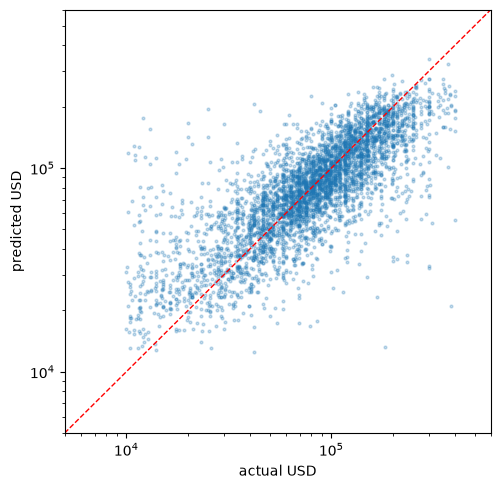

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(np.expm1(y), np.expm1(oof_model), s=4, alpha=.25)
lims = [5e3, 6e5]
ax.plot(lims, lims, "r--", lw=1)            # perfect prediction line
ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims,
       xlabel="actual USD", ylabel="predicted USD")


## What the 10 worst predictions have in common

**Every one is an under-prediction.** Not one of the ten misses by guessing too high. Across all
4,414 rows the split is 50.6% under and 49.4% over, so this is not a global bias -- the model is
even-handed in the middle and systematically short only at the top.

That is the log-space squared-error loss behaving correctly. It settles near the middle of the
conditional distribution, and salary stays right-skewed even after `log1p`, so committing to an
extreme value is never the safe bet. The model is being rational and still being useless for these
people, which are two different things.

**Six are high earners in low-median countries** -- India, Kenya, Paraguay, Iran, China and
Portugal, all reporting $290k-$384k. `Country` is by far the strongest feature, so it anchors these
respondents near their national median and nothing else in `X` is strong enough to pull them out.
The single US row is the mirror image: at 38 years of experience the model still predicts $153k
against an actual $400k.

**Five report a perfectly round figure** -- $300,000 three times, $400,000 twice -- and two more are
round euro amounts wearing dollar clothes: $290,037 and $371,247 are 250,000 and 320,000 EUR at the
1.16014 rate from section 2. Seven of the ten worst rows are therefore self-reported round numbers,
a reminder that some of this error is imprecision in the target rather than failure in the model.

**Two sit exactly on the $400,000 trim ceiling**, so their true values are unknowable from this
file. They may be $400k, or the clipped remains of something much larger.

**Three have 5 or fewer years of experience** while earning above $300k, contradicting the model's
second-strongest feature at the same time as its first.

## The honest read

There is a pattern, and it is not a fixable one. These are people whose pay is not derivable from
the questions this survey asked -- no equity, no employer, no seniority band, no sub-national
location. Someone at a US company's remote office in Nairobi looks identical, across these 16
columns, to someone at a local Kenyan firm.

Ranking by absolute dollar error also guarantees this list skews to high earners. Ranking by error
in log space would surface a different ten, probably low-salary rows the model overshot. Both are
worth reading; only one of them is in this notebook.


In [19]:
worst = pd.DataFrame({
    "Country": df.Country.values,      # why: .values throughout -- y and oof_model are positional arrays, and df's index still has clean()'s gaps in it
    "WorkExp": df.WorkExp.values,
    "DevType": df.DevType.values,
    "actual": np.expm1(y),
    "predicted": np.expm1(oof_model),
})
worst["abs_error"] = (worst.actual - worst.predicted).abs()
worst.nlargest(10, "abs_error").round(0)


,Country,WorkExp,DevType,actual,predicted,abs_error
1779,India,3.0,"Developer, back-end",383591.0,20964.0,362627.0
3035,Japan,15.0,"Developer, full-stack",400000.0,55392.0,344608.0
1930,Netherlands,15.0,"Developer, full-stack",371247.0,100898.0,270349.0
3461,China,3.0,"Developer, desktop or enterprise applications",300000.0,32136.0,267864.0
892,Kenya,3.0,"Developer, front-end",300000.0,33171.0,266829.0
4077,"Iran, Islamic Republic of...",6.0,"Developer, front-end",308605.0,53870.0,254735.0
3662,United States of America,38.0,"Developer, desktop or enterprise applications",400000.0,152871.0,247129.0
3623,Portugal,29.0,"Developer, full-stack",290037.0,59672.0,230365.0
3955,United Kingdom of Great Britain and Northern I...,5.0,AI/ML engineer,340354.0,111496.0,228858.0
2156,Paraguay,18.0,"Developer, full-stack",300000.0,72193.0,227807.0


---
# 8. Limitations

The first question deserves a number rather than an opinion, so it gets a cell.


In [20]:
from sklearn.inspection import permutation_importance

_tr, _te = next(iter(kf.split(X)))     # why: fit on one fold's training rows and permute the held-out ones -- permuting rows the model was fitted on measures memorisation, not reliance
model.fit(X.iloc[_tr], y[_tr])
_imp = pd.Series(
    permutation_importance(model, X.iloc[_te], y[_te], n_repeats=5,
                           random_state=RANDOM_SEED, scoring='r2').importances_mean,
    index=X.columns).sort_values(ascending=False)

_tech = [c for c in X.columns if c.startswith(('lang_', 'db_'))]
print(_imp.head(6).round(4).to_string())
print(f"\nCountry                   {_imp['Country']:.4f}")
print(f"everything except Country {_imp.drop('Country').sum():.4f}")
print(f"all {len(_tech)} tech columns       {_imp[_tech].sum():.4f}")


Country          0.4256
WorkExp          0.1168
currency_code    0.0822
OrgSize_ord      0.0296
DevType          0.0276
YearsCode        0.0264

Country                   0.4256
everything except Country 0.4107
all 72 tech columns       0.0775


### How much of this is just `Country`?

Most of it. Shuffling `Country` costs the model **0.426 of R2_log**; shuffling each of the other 83
features and summing the damage comes to 0.411. One column outweighs everything else put together,
and accounts for 51% of the total measured importance.

Section 5 says the same thing from the other direction: a country-median lookup with no model at
all reaches R2_log 0.375 against the model's 0.598. Two independent methods, one conclusion. And
0.426 is if anything a floor, because `currency_code` is highly correlated with `Country`, so
permuting either alone lets the model partly recover through the other.

The other striking figure is that all 72 multi-hot language and database columns together are worth
0.078 -- less than `currency_code` alone at 0.082. The tech-stack block is the largest thing in the
feature set by column count and nearly the smallest by contribution.

### How wrong is the model in practice?

MAE is $27,808 against a median salary of $82,419, so the average miss is **33.7% of a typical
salary**. Only 45% of predictions land within 20% of the truth, and 24% within 10%.

That is not good enough to price an individual offer and I would not use it that way. Telling a
candidate to expect $80,000 when the honest interval spans roughly $55,000 to $115,000 is false
precision, not information. It is defensible for aggregate statements -- comparing typical pay
across countries or roles, where errors average out -- and it is arguably most useful inverted, as
a null model whose large residuals flag the people worth asking about.

### Who is this model actually valid for?

Everyone here took the Stack Overflow survey, reached the compensation question, chose to answer
it, and gave a figure that survived a $10k-$400k trim. That is a self-selected slice of a
self-selected slice, and the people it excludes are not randomly distributed -- someone who feels
badly underpaid has an obvious reason to skip the question.

The failure is unevenly distributed in a way that matters. Grouping respondents by how many people
share their country, MAE as a share of that group's median salary runs 77% for countries with under
10 respondents, 37% for 10-49, 33% for 50-199 and 29% for 200+. The model serves well-surveyed rich
markets best and everyone else worst, which is backwards from where pay information is scarcest.
Those same respondents are the 34 rows that fell back to the global median in section 5.

One thing I would not do with this model is use it to set pay. It learned the existing gap between
countries, and used prescriptively it would reproduce that gap while making it look like an
objective finding.

### What I would do differently, ranked

1. **Pull `CompFreq` from the full public survey** and use it to audit the low tail. The 124
   sub-$1,000 rows are currently trimmed on suspicion; with the frequency column they could be
   repaired or removed on evidence, and the floor would stop being a judgement call.
2. **Recover the pre-conversion local-currency amounts.** Section 2 shows the target was rounded in
   local currency then converted at one fixed rate. Modelling the local figure and converting
   afterwards would stop the model fitting exchange-rate arithmetic, and would make the $400k
   ceiling mean the same thing in every country.
3. **Add sub-national location.** "United States" spans San Francisco and rural Alabama as one
   level, and `Country` already carries half the model. Splitting the largest countries by region
   is the highest-value feature still in reach.
4. **Report error by country sample size as a standing metric.** The 77%-versus-29% gap above is
   the most actionable weakness in this notebook and it took one groupby to find. It belongs in the
   evaluation table, not in a limitations note written afterwards.


### What the floor does to poor countries

`MIN_SALARY` is justified in section 3 as a data-quality filter, and it is measured there against
R2_log. But R2_log is an average over survivors, so it cannot see *who* stopped being a survivor.
Grouping the dropped rows by country asks that question instead.

In [21]:
MIN_COUNTRY_N = 5     # why: below this a country's own median is too noisy to judge its rows against
N_SD = 3.0            # why: matches the flat band's intent -- cut the far tail, not the shape

def country_relative_keep(frame, n_sd=N_SD, min_n=MIN_COUNTRY_N):
    """Keep rows within n_sd of their own country's median, measured on the log ratio."""
    s = frame.annual_salary_usd
    counts = frame.Country.map(frame.Country.value_counts())
    logr = np.log(s / frame.groupby("Country").annual_salary_usd.transform("median"))
    sd = logr[counts >= min_n].std()          # why: one global spread, estimated only on countries big enough to contribute a stable ratio
    return np.where(counts < min_n,           # why: thin countries have no usable median, so they keep the flat band rather than a number built from 2 rows
                    s.between(MIN_SALARY, MAX_SALARY),
                    logr.abs() <= n_sd * sd)

_salaried = df_raw.dropna(subset=["annual_salary_usd"])
_flat_drop = ~_salaried.annual_salary_usd.between(MIN_SALARY, MAX_SALARY)
_rel_drop = ~country_relative_keep(_salaried)

retention = (pd.DataFrame({"country": _salaried.Country,
                           "flat": _flat_drop, "relative": _rel_drop})
             .groupby("country").agg(n=("flat", "size"),
                                     flat_pct=("flat", "mean"),
                                     rel_pct=("relative", "mean")))
retention = retention[retention.n >= 15].sort_values("flat_pct", ascending=False)

print("share of each country's salaried rows removed, n >= 15\n")
print((retention.head(10) * [1, 100, 100]).round(1).to_string())
print(f"\ncountries losing >20% of their rows -- flat band: {(retention.flat_pct > .2).sum()}, "
      f"country-relative: {(retention.rel_pct > .2).sum()}")
print(f"worst single country -- flat band: {retention.flat_pct.max():.1%}, "
      f"country-relative: {retention.rel_pct.max():.1%}")

share of each country's salaried rows removed, n >= 15

                                n  flat_pct  rel_pct
country                                             
Nigeria                        15      73.3     33.3
Bangladesh                     23      69.6      8.7
Viet Nam                       15      66.7     13.3
Pakistan                       19      52.6      0.0
Iran, Islamic Republic of...   20      40.0      5.0
Ukraine                       160      33.1      8.1
India                         242      30.2      2.1
Colombia                       29      27.6     13.8
Serbia                         29      27.6     10.3
Mexico                         34      26.5      2.9

countries losing >20% of their rows -- flat band: 11, country-relative: 1
worst single country -- flat band: 73.3%, country-relative: 33.3%


### The same model under a fairer rule

The table above is an argument for changing the trim, so the honest next step is to measure what
changing it costs rather than assert that it is free. `clean()` takes the rule as a parameter, so
this is the identical pipeline over a different row set.

In [22]:
df_rel = clean(df_raw, trim=country_relative_keep)      # why: same function, same dedup, same currency fix -- only the trim differs
X_rel, y_rel, mask_rel = build_features(df_rel)

oof_rel = cross_val_predict(
    HistGradientBoostingRegressor(categorical_features=mask_rel, random_state=RANDOM_SEED,
                                  max_iter=300, learning_rate=0.06),   # why: identical settings to section 6
    X_rel, y_rel,
    cv=KFold(N_FOLDS, shuffle=True, random_state=RANDOM_SEED),         # why: a fresh splitter -- the row set differs, so section 6's folds do not apply
)

print(f"flat band       : {len(df):,} rows")
print(f"country-relative: {len(df_rel):,} rows\n")
print(pd.DataFrame([report("flat band (shipped)", y, oof_model),
                    report("country-relative",    y_rel, oof_rel)])
      .set_index("model").round({"MAE": 0, "MedAE": 0, "RMSE": 0, "R2_log": 3}).to_string())

flat band       : 4,414 rows
country-relative: 4,775 rows

                         MAE    MedAE     RMSE  R2_log
model                                                 
flat band (shipped)  27808.0  17409.0  43297.0   0.598
country-relative     34831.0  18922.0  81197.0   0.556


### Reading that comparison

The country-relative rule keeps 361 more rows and cuts the number of countries losing over a fifth
of their respondents from 11 to 1. Nigeria goes from losing 73.3% to 33.3%, Pakistan from 52.6% to
none. On fairness of coverage it is plainly the better rule.

It also scores worse: MAE $34,831 against $27,808, R2_log 0.556 against 0.598.

**Those two numbers are not directly comparable, and the gap is not evidence the model got worse.**
They are computed over different populations. The country-relative set retains 361 rows the flat
band deleted, and those rows are disproportionately low-income-country respondents and genuine
extremes -- the hardest rows in the file. A model scored on a harder population posts a worse
number while being the same model.

Which is the finding. **Part of the headline R2_log 0.598 is bought by deleting the respondents the
model would have been worst at**, and a flat dollar floor is the mechanism: it encodes an
assumption that $10,000 means the same thing in Lagos and in San Francisco. The 0.598 is not wrong,
but it describes a population the filter has already made easier, and it should be read that way.

I have kept the flat band as shipped, because changing it late would invalidate every measurement
in sections 3 through 7 and I would rather report a weakness I have quantified than a rebuild I
have not checked. With more time this is the first thing I would change, and it is coupled to a
second: a country-relative rule keeps more thin-country rows, which is exactly the situation where
a raw `Country` category with no shrinkage starts to hurt. The two changes belong in the same move.

---
# 9. Save outputs

In [23]:
import pathlib
pathlib.Path("outputs").mkdir(exist_ok=True)

results.to_json("outputs/metrics.json", indent=2)
pd.DataFrame({
    "ResponseId": df.ResponseId.values,
    "actual":     np.expm1(y),
    "predicted":  np.expm1(oof_model),
    "abs_error":  np.abs(np.expm1(y) - np.expm1(oof_model)),
}).to_csv("outputs/predictions.csv", index=False)
print("wrote outputs/metrics.json and outputs/predictions.csv")

wrote outputs/metrics.json and outputs/predictions.csv
